# Imports

In [ ]:
import matplotlib.pyplot as plt
from google.colab import drive
from pathlib import Path
import pandas as pd
import numpy as np
# mount the Drive
drive.mount('/content/drive')
# This is the folder path where all our project files are stored in Google Drive
BASE_DIR = Path('/content/drive/MyDrive/SmartCities')
# List of all 5 raw accident CSV files we need — one file per year
required_files = [
    'Unfallorte2020_LinRef.csv',
    'AfSBBB_BE_LOR_Strasse_Strassenverkehrsunfaelle_2021_Datensatz.csv',
    'Unfallorte2022_LinRef.csv',
    'Unfallorte2023_LinRef.csv',
    'Unfallorte2024_LinRef.csv'
]

for file in required_files:
    path = BASE_DIR / file
    print(file, "FOUND" if path.exists() else "MISSING")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Unfallorte2020_LinRef.csv FOUND
AfSBBB_BE_LOR_Strasse_Strassenverkehrsunfaelle_2021_Datensatz.csv FOUND
Unfallorte2022_LinRef.csv FOUND
Unfallorte2023_LinRef.csv FOUND
Unfallorte2024_LinRef.csv FOUND


# Loading the raw data

In [ ]:
def fix_coord(col):
    return col.astype(str).str.replace(',', '.').str.rstrip('.').astype(float)

# 2021 (different structure — Berlin only file)
df2021 = pd.read_csv(BASE_DIR / 'AfSBBB_BE_LOR_Strasse_Strassenverkehrsunfaelle_2021_Datensatz.csv', sep=';')
df2021 = df2021.rename(columns={'YGCSWGS84,,,,': 'YGCSWGS84', 'LAND': 'ULAND', 'USTRZUSTAND': 'STRZUSTAND'})
df2021['XGCSWGS84'] = fix_coord(df2021['XGCSWGS84'])
df2021['YGCSWGS84'] = fix_coord(df2021['YGCSWGS84'])
df2021['YEAR'] = 2021

# 2020, 2022, 2023, 2024 (same structure)
other_files = {
    2020: 'Unfallorte2020_LinRef.csv',
    2022: 'Unfallorte2022_LinRef.csv',
    2023: 'Unfallorte2023_LinRef.csv',
    2024: 'Unfallorte2024_LinRef.csv',
}

dfs = []

for year, fname in other_files.items():
    df = pd.read_csv(BASE_DIR / fname, sep=';', low_memory=False)
    df = df[df['ULAND'] == 11].copy()  # Filter Berlin only
    df['YEAR'] = year
    df['XGCSWGS84'] = fix_coord(df['XGCSWGS84'])
    df['YGCSWGS84'] = fix_coord(df['YGCSWGS84'])
    dfs.append(df)
    print(f"{year}: {len(df)} Berlin accidents loaded")

print(f"2021: {len(df2021)} Berlin accidents loaded")

2020: 11810 Berlin accidents loaded
2022: 12348 Berlin accidents loaded
2023: 12329 Berlin accidents loaded
2024: 12428 Berlin accidents loaded
2021: 11267 Berlin accidents loaded


# Harmonizing yearly datasets

In [ ]:
# These columns exist in ALL years
common_cols = [
    'UJAHR', 'UMONAT', 'USTUNDE', 'UWOCHENTAG',
    'UKATEGORIE', 'UART', 'UTYP1', 'ULICHTVERH',
    'IstRad', 'IstPKW', 'IstFuss', 'IstKrad',
    'IstGkfz', 'IstSonstige',
    'LINREFX', 'LINREFY', 'XGCSWGS84', 'YGCSWGS84', 'YEAR'
]

# Remove STRZUSTAND — not consistent across years
df2021_clean = df2021[[c for c in common_cols if c in df2021.columns]].copy()
other_clean = [df[[c for c in common_cols if c in df.columns]].copy() for df in dfs]

# Merge all years
all_years = pd.concat([df2021_clean] + other_clean, ignore_index=True)

print(f"Total Berlin accidents (all years): {len(all_years)}")
print(f"Years: {sorted(all_years['YEAR'].unique())}")

Total Berlin accidents (all years): 60182
Years: [np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]


In [ ]:
pedestrians_all = all_years[all_years['IstFuss'] == 1].copy()

print("Pedestrian accidents by year:")
print(pedestrians_all.groupby('YEAR').size())
print(f"\nTotal pedestrian accidents (all years): {len(pedestrians_all)}")

Pedestrian accidents by year:
YEAR
2020    1396
2021    1460
2022    1569
2023    1794
2024    1712
dtype: int64

Total pedestrian accidents (all years): 7931


## Assigning readable labels to the data

In [ ]:
severity_map = {1: 'Fatal', 2: 'Serious Injury', 3: 'Minor Injury'}
lighting_map = {0: 'Daylight', 1: 'Dusk / Dawn', 2: 'Darkness'}
day_map = {1: 'Sunday', 2: 'Monday', 3: 'Tuesday',
           4: 'Wednesday', 5: 'Thursday', 6: 'Friday', 7: 'Saturday'}
month_map = {1: 'January', 2: 'February', 3: 'March', 4: 'April',
             5: 'May', 6: 'June', 7: 'July', 8: 'August',
             9: 'September', 10: 'October', 11: 'November', 12: 'December'}
accident_type_map = {
    0: 'Other', 1: 'Driving accident', 2: 'Turning accident',
    3: 'Turning/Crossing accident', 4: 'Crossing accident',
    5: 'Pedestrian accident', 6: 'Longitudinal accident',
    7: 'Stationary vehicle accident', 8: 'Other', 9: 'Other'
}

pedestrians_all['Severity']      = pedestrians_all['UKATEGORIE'].map(severity_map)
pedestrians_all['Lighting']      = pedestrians_all['ULICHTVERH'].map(lighting_map)
pedestrians_all['Day']           = pedestrians_all['UWOCHENTAG'].map(day_map)
pedestrians_all['Month']         = pedestrians_all['UMONAT'].map(month_map)
pedestrians_all['Accident_Type'] = pedestrians_all['UTYP1'].map(accident_type_map)


print(pedestrians_all[['YEAR', 'Severity', 'Lighting', 'Day', 'Month']].head(10))

Labels added!
    YEAR        Severity  Lighting        Day     Month
1   2021    Minor Injury  Darkness   Saturday  December
9   2021    Minor Injury  Darkness     Monday  December
12  2021    Minor Injury  Daylight    Tuesday  December
13  2021    Minor Injury  Darkness  Wednesday  December
15  2021    Minor Injury  Darkness   Thursday  December
16  2021    Minor Injury  Darkness   Thursday  December
21  2021    Minor Injury  Darkness   Saturday  December
23  2021  Serious Injury  Daylight     Monday  December
25  2021    Minor Injury  Darkness     Monday  December
29  2021  Serious Injury  Darkness     Monday  December


In [ ]:
print("=" * 45)
print("MERGED DATASET OVERVIEW")
print("=" * 45)

print(f"\nTotal rows: {len(pedestrians_all)}")
print(f"Years: {sorted(pedestrians_all['YEAR'].unique())}")

print("\nPedestrian accidents per year:")
print(pedestrians_all.groupby('YEAR').size())

print("\nSeverity breakdown (all years):")
print(pedestrians_all['Severity'].value_counts())

print("\nMissing values:")
print(pedestrians_all.isnull().sum()[pedestrians_all.isnull().sum() > 0])

MERGED DATASET OVERVIEW

Total rows: 7931
Years: [np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]

Pedestrian accidents per year:
YEAR
2020    1396
2021    1460
2022    1569
2023    1794
2024    1712
dtype: int64

Severity breakdown (all years):
Severity
Minor Injury      6034
Serious Injury    1825
Fatal               72
Name: count, dtype: int64

Missing values:
Series([], dtype: int64)


## Saving the processed data

In [ ]:
output_path = BASE_DIR / 'berlin_pedestrians_2020_2024.csv'

pedestrians_all.to_csv(output_path, index=False)

print("Merged dataset saved to:")
print(output_path)

df = pedestrians_all.copy()

print("Dataset ready for analysis:", df.shape)

Merged dataset saved to:
/content/drive/MyDrive/SmartCities/berlin_pedestrians_2020_2024.csv
Dataset ready for analysis: (7931, 24)


# Visualizations

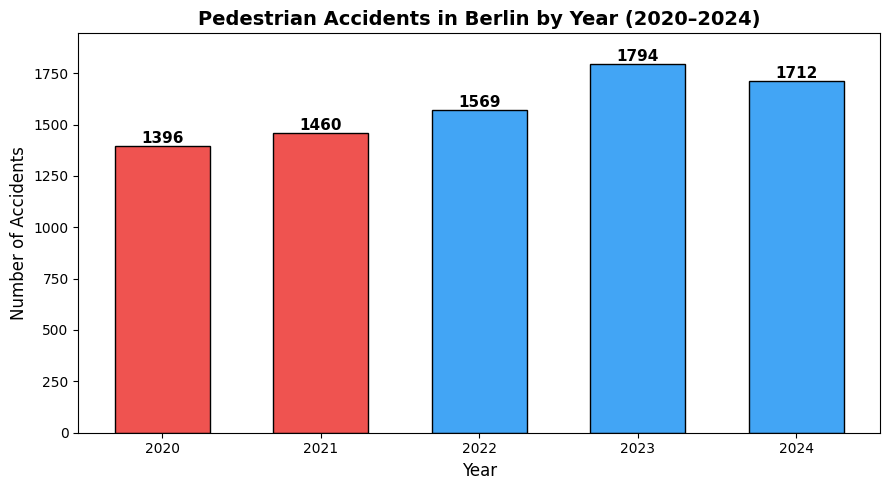

Saved!


In [ ]:
year_counts = df.groupby('YEAR').size()

plt.figure(figsize=(9, 5))
bars = plt.bar(year_counts.index, year_counts.values,
               color=['#ef5350','#ef5350','#42a5f5','#42a5f5','#42a5f5'],
               edgecolor='black', width=0.6)

for bar, val in zip(bars, year_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
             str(val), ha='center', fontweight='bold', fontsize=11)

plt.title('Pedestrian Accidents in Berlin by Year (2020–2024)', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Accidents', fontsize=12)
plt.xticks(year_counts.index)
plt.ylim(0, max(year_counts.values) + 150)
plt.tight_layout()
plt.savefig('chart1_accidents_per_year.png', dpi=150)
plt.show()
print("Saved!")

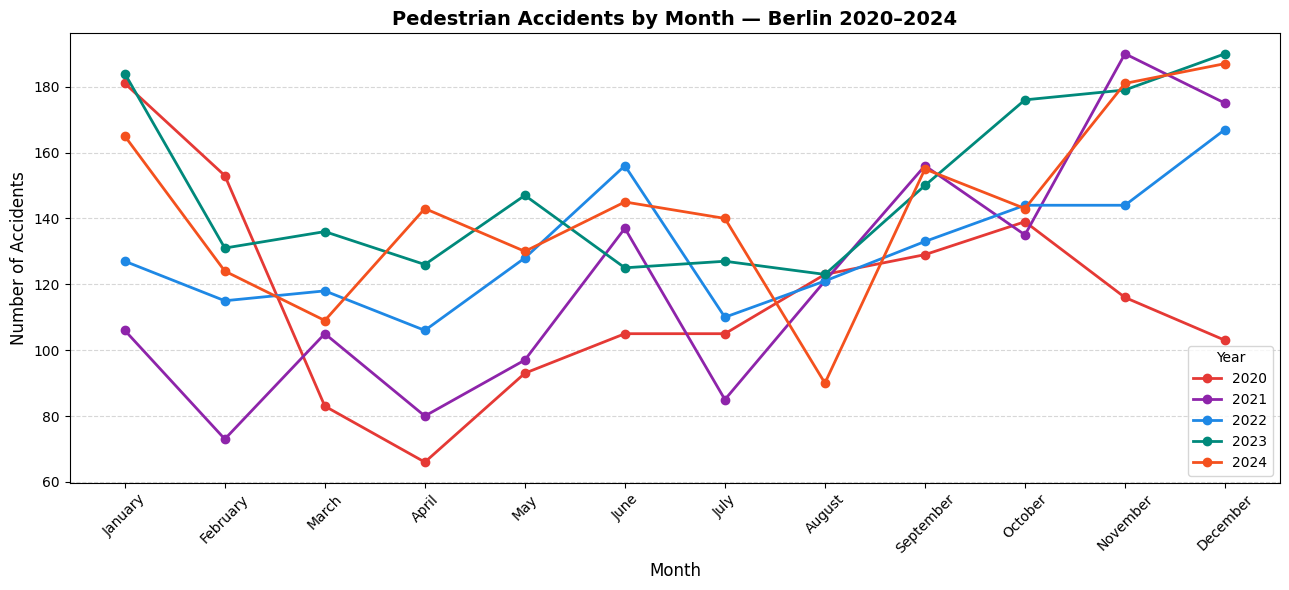

Saved!


In [ ]:
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']

plt.figure(figsize=(13, 6))
colors = ['#e53935','#8e24aa','#1e88e5','#00897b','#f4511e']

for i, year in enumerate([2020, 2021, 2022, 2023, 2024]):
    year_df = df[df['YEAR'] == year]
    month_counts = year_df['Month'].value_counts().reindex(month_order).fillna(0)
    plt.plot(month_order, month_counts.values, marker='o',
             label=str(year), color=colors[i], linewidth=2)

plt.title('Pedestrian Accidents by Month — Berlin 2020–2024', fontsize=14, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Number of Accidents', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Year', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('chart2_monthly_trends.png', dpi=150)
plt.show()
print("Saved!")

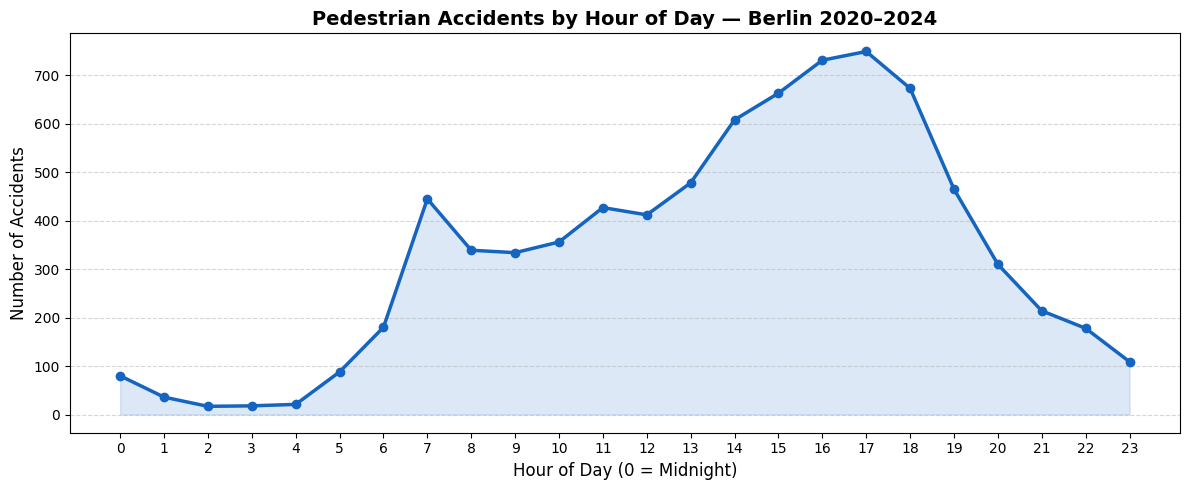

Saved!


In [ ]:
hour_counts = df.groupby('USTUNDE').size()

plt.figure(figsize=(12, 5))
plt.plot(hour_counts.index, hour_counts.values,
         marker='o', color='#1565c0', linewidth=2.5)
plt.fill_between(hour_counts.index, hour_counts.values,
                 alpha=0.15, color='#1565c0')

plt.title('Pedestrian Accidents by Hour of Day — Berlin 2020–2024', fontsize=14, fontweight='bold')
plt.xlabel('Hour of Day (0 = Midnight)', fontsize=12)
plt.ylabel('Number of Accidents', fontsize=12)
plt.xticks(range(0, 24))
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('chart3_hourly.png', dpi=150)
plt.show()
print("Saved!")

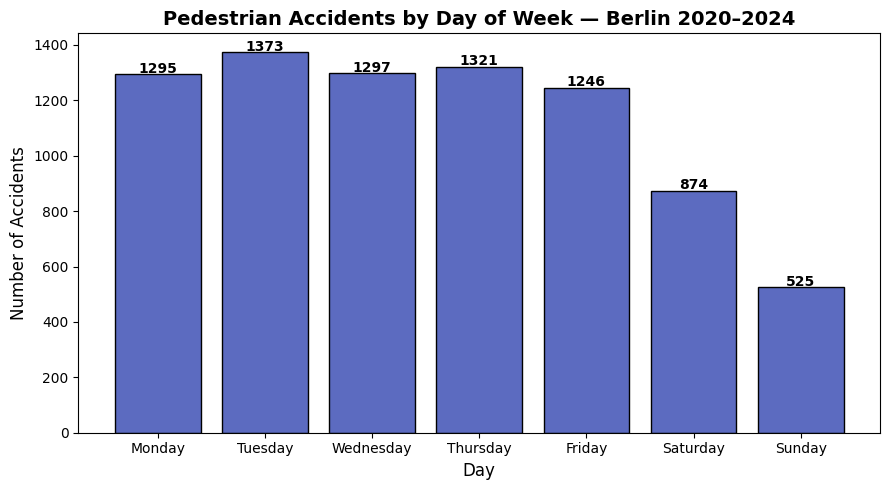

Saved!


In [ ]:
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
day_counts = df['Day'].value_counts().reindex(day_order)

plt.figure(figsize=(9, 5))
bars = plt.bar(day_counts.index, day_counts.values,
               color='#5c6bc0', edgecolor='black')

for bar, val in zip(bars, day_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             str(val), ha='center', fontsize=10, fontweight='bold')

plt.title('Pedestrian Accidents by Day of Week — Berlin 2020–2024', fontsize=14, fontweight='bold')
plt.xlabel('Day', fontsize=12)
plt.ylabel('Number of Accidents', fontsize=12)
plt.tight_layout()
plt.savefig('chart4_day_of_week.png', dpi=150)
plt.show()
print("Saved!")

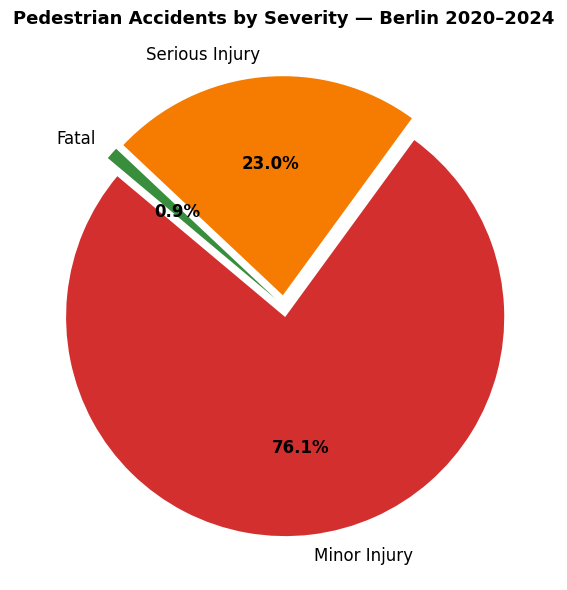

Saved!


In [ ]:
severity_counts = df['Severity'].value_counts()

colors = ['#d32f2f', '#f57c00', '#388e3c']
explode = (0.05, 0.05, 0.05)

plt.figure(figsize=(7, 6))
wedges, texts, autotexts = plt.pie(
    severity_counts.values,
    labels=severity_counts.index,
    colors=colors,
    autopct='%1.1f%%',
    explode=explode,
    startangle=140,
    textprops={'fontsize': 12}
)
for autotext in autotexts:
    autotext.set_fontweight('bold')

plt.title('Pedestrian Accidents by Severity — Berlin 2020–2024', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('chart5_severity.png', dpi=150)
plt.show()
print("Saved!")

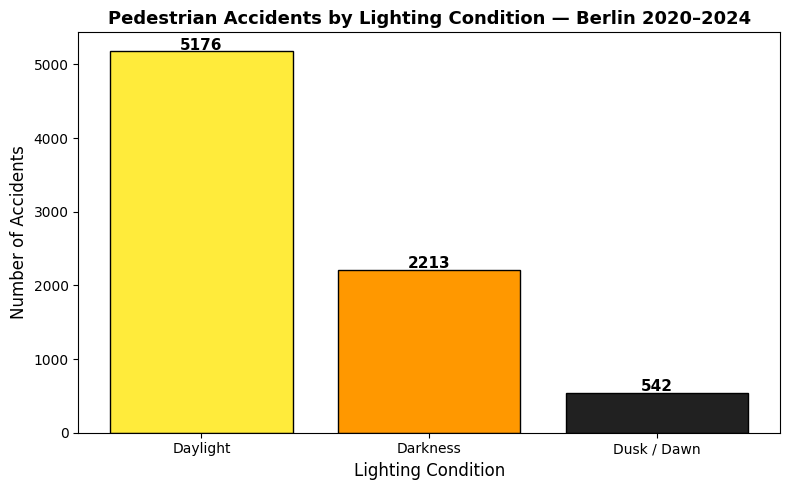

Saved!


In [ ]:
lighting_counts = df['Lighting'].value_counts()

colors = ['#ffeb3b', '#ff9800', '#212121']
plt.figure(figsize=(8, 5))
bars = plt.bar(lighting_counts.index, lighting_counts.values,
               color=colors, edgecolor='black')

for bar, val in zip(bars, lighting_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
             str(val), ha='center', fontweight='bold', fontsize=11)

plt.title('Pedestrian Accidents by Lighting Condition — Berlin 2020–2024', fontsize=13, fontweight='bold')
plt.xlabel('Lighting Condition', fontsize=12)
plt.ylabel('Number of Accidents', fontsize=12)
plt.tight_layout()
plt.savefig('chart6_lighting.png', dpi=150)
plt.show()
print("Saved!")

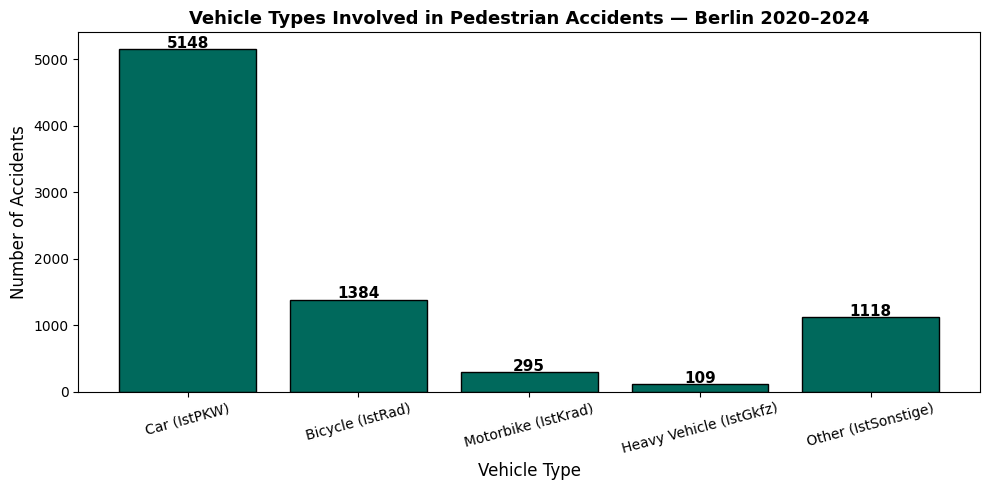

Saved!


In [ ]:
vehicle_data = {
    'Car (IstPKW)': df['IstPKW'].sum(),
    'Bicycle (IstRad)': df['IstRad'].sum(),
    'Motorbike (IstKrad)': df['IstKrad'].sum(),
    'Heavy Vehicle (IstGkfz)': df['IstGkfz'].sum(),
    'Other (IstSonstige)': df['IstSonstige'].sum()
}

plt.figure(figsize=(10, 5))
bars = plt.bar(vehicle_data.keys(), vehicle_data.values(),
               color='#00695c', edgecolor='black')

for bar, val in zip(bars, vehicle_data.values()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
             str(int(val)), ha='center', fontweight='bold', fontsize=11)

plt.title('Vehicle Types Involved in Pedestrian Accidents — Berlin 2020–2024', fontsize=13, fontweight='bold')
plt.xlabel('Vehicle Type', fontsize=12)
plt.ylabel('Number of Accidents', fontsize=12)
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('chart7_vehicle_type.png', dpi=150)
plt.show()
print("Saved!")

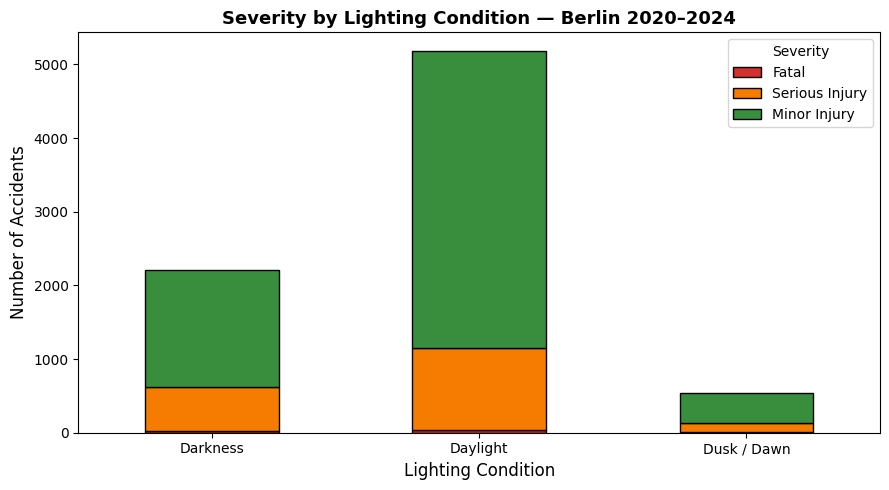

Saved!


In [ ]:
lighting_severity = df.groupby(['Lighting', 'Severity']).size().unstack(fill_value=0)
lighting_severity = lighting_severity[['Fatal', 'Serious Injury', 'Minor Injury']]

colors = ['#d32f2f', '#f57c00', '#388e3c']
lighting_severity.plot(kind='bar', figsize=(9, 5), color=colors,
                       edgecolor='black', stacked=True)

plt.title('Severity by Lighting Condition — Berlin 2020–2024', fontsize=13, fontweight='bold')
plt.xlabel('Lighting Condition', fontsize=12)
plt.ylabel('Number of Accidents', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Severity', fontsize=10)
plt.tight_layout()
plt.savefig('chart9_severity_by_lighting.png', dpi=150)
plt.show()
print("Saved!")

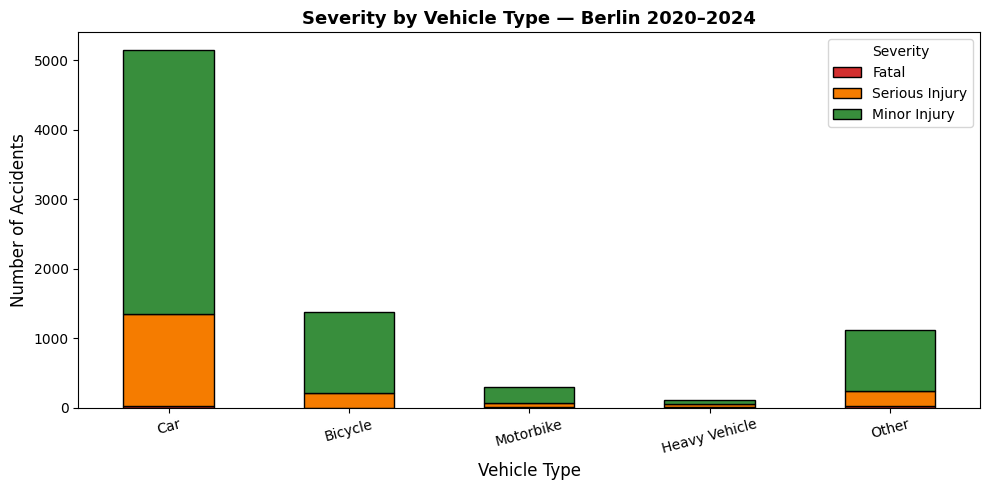

Saved!


In [ ]:
vehicle_cols = {'Car': 'IstPKW', 'Bicycle': 'IstRad',
                'Motorbike': 'IstKrad', 'Heavy Vehicle': 'IstGkfz',
                'Other': 'IstSonstige'}

severity_by_vehicle = {}
for label, col in vehicle_cols.items():
    involved = df[df[col] == 1]
    severity_by_vehicle[label] = involved['Severity'].value_counts()

sv_df = pd.DataFrame(severity_by_vehicle).T.fillna(0)
sv_df = sv_df[['Fatal', 'Serious Injury', 'Minor Injury']]

colors = ['#d32f2f', '#f57c00', '#388e3c']
sv_df.plot(kind='bar', figsize=(10, 5), color=colors,
           edgecolor='black', stacked=True)

plt.title('Severity by Vehicle Type — Berlin 2020–2024', fontsize=13, fontweight='bold')
plt.xlabel('Vehicle Type', fontsize=12)
plt.ylabel('Number of Accidents', fontsize=12)
plt.xticks(rotation=15)
plt.legend(title='Severity', fontsize=10)
plt.tight_layout()
plt.savefig('chart10_severity_by_vehicle.png', dpi=150)
plt.show()
print("Saved!")